# B/D/C1/C2/C Scorecard and Verdict — Demo

This notebook demonstrates `eval.py`, which consolidates a five-condition (**B**, **D**, **C1**, **C2**, **C**) span-editing repair comparison into one statistically-audited scorecard.

What it does, in order:

1. **Per-row COMET availability gate** — searches every upstream artifact's JSON for a per-row COMET field. None exists (only pooled/per-language-pair aggregates are stored), so this is recorded explicitly rather than assumed.
2. **True paired bootstrap** (2000 resamples, seed=42) on `fix_rate` and `true_regression_rate`, which genuinely exist per-row on the 240 matched injected-pool rows.
3. A **disjoint-population check**: the COMET population (320 natural rows) and the fix-rate population (240 injected rows) must not overlap.
4. **Fix-rate-advantage reconciliation** — reconciles a reviewer-flagged discrepancy between the fix-rate advantage computed including vs. excluding structural non-attempt (negation-deletion) rows.
5. **Condition C verdict** — evaluates three pre-registered success criteria; in the real run, Condition C's own artifact had not yet completed, so its verdict is `UNDETERMINED_NO_ARTIFACT`.
6. A **full scorecard** table across all available conditions.

This demo runs the exact same logic on a small curated subset (`mini_demo_data.json`, ~20 natural + 24 injected rows spanning both language pairs and all four invariant categories) so it finishes in well under a minute, instead of the full 320/240-row dataset.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (Colab guard)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import sys

import numpy as np
from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data

`mini_demo_data.json` is a curated subset of the four upstream artifacts `eval.py` reads:

- `bdc1` — the combined **B/D/C1** repair run (`full_method_out.json` from `art_7Uc5PlFctjXi`), with 20 natural rows (10 per language pair) and 24 injected-pool rows (3 per language-pair x invariant-category cell, covering both `en-ru_RU`/`en-uk_UA` and all four invariant categories: `named_entity_swap`, `number_unit_date_alteration`, `negation_polarity_flip`, `quantifier_substitution`).
- `c2` — the **C2** (checker-broadened localization) run (`art_K8koUmGFDlLN`), subset to the exact same `metadata_row_id`s as `bdc1` above, so every pairwise comparison below is still genuinely paired on matched rows.
- `checker_validation` — the checker-validation table (`art_QLpPxaqf1VzK`), subset to the `ru_RU`/`uk_UA` rows used as a scorecard footnote.
- `dataset_preview` — a stub; the original script loads this dependency but never uses its contents in any computation.

In the real run, a fifth condition (**Condition C**) is looked up by scanning this iteration's sibling `gen_art` directories for a completed artifact at run time. That artifact had not finished when the real evaluation ran, so Condition C's status was `not_found` — this demo reproduces that same outcome directly (see the Condition C section below) rather than re-implementing directory scanning, which has no meaning outside the original pipeline's folder layout.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-4/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
bdc1 = data["bdc1"]
c2 = data["c2"]
checker_validation = data["checker_validation"]
dataset_preview = data["dataset_preview"]
logger.info("Loaded B/D/C1, C2, checker-validation, dataset preview")

bdc1_natural = {e["metadata_row_id"]: e for e in bdc1["datasets"][0]["examples"]}
bdc1_injected = {e["metadata_row_id"]: e for e in bdc1["datasets"][1]["examples"]}
c2_natural = {e["metadata_row_id"]: e for e in c2["datasets"][0]["examples"]}
c2_injected = {e["metadata_row_id"]: e for e in c2["datasets"][1]["examples"]}
logger.info(
    f"B/D/C1 natural={len(bdc1_natural)} injected={len(bdc1_injected)}; "
    f"C2 natural={len(c2_natural)} injected={len(c2_injected)}"
)

11:55:35|INFO   |Loaded B/D/C1, C2, checker-validation, dataset preview


11:55:35|INFO   |B/D/C1 natural=20 injected=24; C2 natural=20 injected=24


## Config

All tunable parameters, gathered in one place. `N_BOOT` (bootstrap resamples) is the one real "scale" knob in this script — the original uses 2000; we start at the minimum useful value and scale up below if time permits. `SEED` and `Z95` are fixed constants from the original script, not scaled.

In [5]:
# --- ORIGINAL values (full run): N_BOOT = 2000 ---
N_BOOT = 200  # bootstrap resamples per paired-diff CI (minimum useful value for a demo)
SEED = 42
Z95 = 1.959963984540054

## Condition C discovery

The original script's `discover_condition_c()` scans this iteration's sibling `gen_art/` directories on disk at run time, looking for a completed Condition C artifact by title/summary keyword match. That scan is meaningless outside the original pipeline's folder layout, so here we reproduce its literal outcome from the real run directly: no Condition C sibling artifact had completed by evaluation time, so `c_load["status"] == "not_found"` — exactly as `full_eval_out.json`'s `step5_condition_c_verdict.discovery` records.

In [6]:
c_discovery = {"found": False, "path": None, "title": None, "justification": None, "scan_log": ["Condition C sibling artifact had not completed by evaluation run time (real-run outcome reproduced directly; see markdown above)."]}
c_load = {"status": "not_found", "data": None, "completion_fraction": None}
logger.info(f"Condition C status: {c_load['status']}")

condition_c_natural = {}
condition_c_injected = {}
per_row_comet_c_available = {"available": False, "json_path": None, "note": "Condition C artifact not found."}
condition_c_pooled_comet = None

11:55:35|INFO   |Condition C status: not_found


## Step 3: disjoint-population check

The COMET metric is computed on the 320-row *natural* population; `fix_rate`/`true_regression_rate` are computed on the 240-row *injected-pool* population. These populations must never overlap, or later steps would be silently mixing two different measurement regimes. This is a literal set intersection over `metadata_row_id`. (In this demo, the populations are the 20-row and 24-row subsets described above — the check is identical, just at a smaller scale.)

In [7]:
comet_row_ids = set(bdc1_natural.keys())
assert comet_row_ids == set(c2_natural.keys()), "natural row-id sets must match across B/D/C1 and C2"
fix_rate_row_ids = set(bdc1_injected.keys())
assert fix_rate_row_ids == set(c2_injected.keys()), "injected row-id sets must match across B/D/C1 and C2"
overlap = comet_row_ids & fix_rate_row_ids
disjoint_population_check = {
    "comet_population_n": len(comet_row_ids),
    "fix_rate_population_n": len(fix_rate_row_ids),
    "overlap_count": len(overlap),
    "overlap_row_ids": sorted(overlap),
    "verified": len(overlap) == 0,
}
logger.info(f"Disjoint-population check: overlap_count={disjoint_population_check['overlap_count']}")
if disjoint_population_check["overlap_count"] != 0:
    logger.error("DATA-INTEGRITY FINDING: comet and fix-rate row populations overlap unexpectedly")
disjoint_population_check

11:55:35|INFO   |Disjoint-population check: overlap_count=0


{'comet_population_n': 20,
 'fix_rate_population_n': 24,
 'overlap_count': 0,
 'overlap_row_ids': [],
 'verified': True}

## Step 1: per-row COMET availability gate

Rather than assuming per-row COMET scores exist (they would be needed for a true paired bootstrap on DeltaCOMET), the script *falsifiably* searches every upstream JSON for a plausible per-row COMET field — recursively through `metadata`, and through every example's own keys — and records exactly what it found (or didn't). This turns "we assumed X" into "we searched for X and here are the exact keys we found instead."

In [8]:
def find_per_row_comet_field(obj, path="", max_depth=6):
    """Recursively search a loaded JSON object for a plausible per-row COMET array."""
    if max_depth <= 0:
        return None
    if isinstance(obj, dict):
        for k, v in obj.items():
            kl = k.lower()
            if isinstance(v, (int, float)) and any(
                tag in kl for tag in ("comet_before", "comet_after", "delta_comet_row", "comet_score")
            ) and "mean" not in kl and "ci95" not in kl:
                return f"{path}.{k}" if path else k
            if isinstance(v, (dict, list)):
                found = find_per_row_comet_field(v, f"{path}.{k}" if path else k, max_depth - 1)
                if found:
                    return found
    elif isinstance(obj, list) and obj:
        sample = obj[0]
        # Only treat this as a candidate PER-ROW array if its length is in the natural-
        # subsample ballpark (>=50); short lists (e.g. per-language-pair aggregates,
        # len==2) are NOT per-row data even if a field name contains "comet".
        if isinstance(sample, dict) and len(obj) >= 50:
            for k in sample:
                kl = k.lower()
                if any(tag in kl for tag in ("comet_before", "comet_after", "delta_comet", "comet_score")):
                    if "mean" not in kl and "ci95" not in kl and "per_edit_volume" not in kl:
                        return f"{path}[].{k}"
        if isinstance(sample, dict):
            found = find_per_row_comet_field(sample, f"{path}[0]", max_depth - 1)
            if found:
                return found
    return None


def check_per_row_comet_availability(label, data):
    examples = []
    for ds in data.get("datasets", []):
        examples.extend(ds.get("examples", []))
    if examples:
        keys = set()
        for ex in examples[:5]:
            keys.update(ex.keys())
        comet_keys = [k for k in keys if "comet" in k.lower()]
        if comet_keys:
            return {"available": True, "json_path": f"datasets[].examples[].{sorted(comet_keys)}", "note": None}
    md_found = find_per_row_comet_field(data.get("metadata", {}))
    if md_found:
        return {"available": True, "json_path": f"metadata.{md_found}", "note": None}
    all_top_keys = sorted(data.keys())
    example_keys = sorted({k for ds in data.get("datasets", []) for ex in ds.get("examples", []) for k in ex})
    return {
        "available": False,
        "json_path": None,
        "note": (
            f"Enumerated top-level keys {all_top_keys} and per-row example keys "
            f"{example_keys[:40]}{'...' if len(example_keys) > 40 else ''} for {label}; "
            "no field matching comet_before/comet_after/delta_comet/comet_score at the row "
            "level was found. Only pooled/per-language-pair aggregate delta_comet_mean + "
            "delta_comet_ci95 are stored (metadata.metrics.*). Per-row edit_volume, "
            "n_llm_calls, fixed, and true_regression ARE stored at row level (see the "
            "fix_rate/true_regression_rate paired-bootstrap results below, which use exactly "
            "this row-level data)."
        ),
    }

In [9]:
logger.info("Step 1: per-row COMET availability check")
per_row_comet_availability = {
    "b": check_per_row_comet_availability("B (within B/D/C1 artifact)", bdc1),
    "d": check_per_row_comet_availability("D (within B/D/C1 artifact)", bdc1),
    "c1": check_per_row_comet_availability("C1 (within B/D/C1 artifact)", bdc1),
    "c2": check_per_row_comet_availability("C2 artifact", c2),
}
for cond, res in per_row_comet_availability.items():
    logger.info(f"  per_row_comet_{cond}_available = {res['available']}")
per_row_comet_availability["c"] = per_row_comet_c_available

11:55:35|INFO   |Step 1: per-row COMET availability check


11:55:35|INFO   |  per_row_comet_b_available = False


11:55:35|INFO   |  per_row_comet_d_available = False


11:55:35|INFO   |  per_row_comet_c1_available = False


11:55:35|INFO   |  per_row_comet_c2_available = False


## Bootstrap helpers

Two estimators:

- `paired_bootstrap_mean_diff` — a **true** paired bootstrap over matched rows (used for `fix_rate`/`true_regression_rate`, which genuinely exist per-row).
- `normal_approx_diff` — a **documented fallback** for DeltaCOMET, since no per-row COMET exists anywhere to pair on. It explicitly states the independence assumption it has to make, and why that assumption is conservative (the true paired test would be narrower).

In [10]:
def paired_bootstrap_mean_diff(x, y, n_boot=N_BOOT, seed=SEED):
    """x, y: same-length arrays of per-row values on MATCHED rows. Returns point estimate + 95% CI."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    assert len(x) == len(y) and len(x) > 0
    d = x - y
    point = float(np.mean(d))
    rng = np.random.default_rng(seed)
    n = len(d)
    idx = rng.integers(0, n, size=(n_boot, n))
    resample_means = d[idx].mean(axis=1)
    lo, hi = np.percentile(resample_means, [2.5, 97.5])
    return {
        "point_estimate": point,
        "ci95": [float(lo), float(hi)],
        "n_matched_rows": int(n),
        "n_boot": n_boot,
        "seed": seed,
        "ci_excludes_zero": bool(lo > 0 or hi < 0),
    }


def normal_approx_diff(mean_x, ci_x, mean_y, ci_y):
    """Independence-assuming normal-approximation fallback for two pooled bootstrap CIs.

    se_diff = sqrt(se_x^2 + se_y^2), each se estimated as the mean CI half-width / 1.96.
    CAVEAT: this assumes X and Y are independent. In fact the two conditions here are
    scored on IDENTICAL matched rows, so a true paired test would exploit that positive
    correlation and yield a narrower (more powerful) CI than this approximation produces.
    This is used ONLY where no per-row data exists to run the true paired test.
    """
    se_x = ((ci_x[1] - ci_x[0]) / 2) / Z95
    se_y = ((ci_y[1] - ci_y[0]) / 2) / Z95
    se_diff = float(np.sqrt(se_x**2 + se_y**2))
    diff = mean_x - mean_y
    lo, hi = diff - Z95 * se_diff, diff + Z95 * se_diff
    return {
        "formula": "se_diff = sqrt(se_x^2 + se_y^2); se_i = (ci_i_upper - ci_i_lower) / 2 / 1.959963984540054",
        "independence_assumption_caveat": (
            "Assumes X and Y are statistically independent. They are NOT: both conditions "
            "are scored on the identical matched row population, so their errors are "
            "positively correlated. A true paired bootstrap would exploit that correlation "
            "for a narrower, more powerful CI than this normal approximation gives. Used only "
            "because no per-row COMET values are stored in any upstream artifact (see step 1)."
        ),
        "se_x": se_x,
        "se_y": se_y,
        "se_diff": se_diff,
        "point_estimate": float(diff),
        "ci95": [float(lo), float(hi)],
        "ci_excludes_zero": bool(lo > 0 or hi < 0),
    }

## Step 2 + 4: fix_rate / true_regression_rate paired bootstrap

For every injected-pool row, `metadata_{cond}_fixed` / `metadata_{cond}_true_regression` genuinely exist per-row, so we can run a **true** paired bootstrap here (as opposed to the DeltaCOMET normal-approximation fallback above). Every comparison is run **both including and excluding** the 60 structural non-attempt negation rows (`negation_polarity_flip`), since those rows are deletions that no masking/repair condition can meaningfully "fix", which mechanically shrinks any measured gap when included.

(Note: the full run asserts exactly 240/180/60 rows; this demo's config-derived counts below reflect the ~24-row subset instead — the assertions check internal consistency of the split, not the literal full-dataset size.)

In [11]:
logger.info("Step 2/4: true paired bootstrap on fix_rate and true_regression_rate")

all_injected_ids = sorted(bdc1_injected.keys())
noneg_injected_ids = sorted(
    rid for rid in all_injected_ids if bdc1_injected[rid]["metadata_invariant_category"] != "negation_polarity_flip"
)
neg_injected_ids = sorted(set(all_injected_ids) - set(noneg_injected_ids))
# full-run values: len(all_injected_ids) == 240, len(noneg_injected_ids) == 180, len(neg_injected_ids) == 60
assert len(all_injected_ids) == len(noneg_injected_ids) + len(neg_injected_ids)
logger.info(f"all={len(all_injected_ids)} noneg={len(noneg_injected_ids)} neg={len(neg_injected_ids)}")


def get_binary(source_dict, row_id, key, fallback_key=None):
    row = source_dict[row_id]
    val = row.get(key)
    if val is None and fallback_key is not None and fallback_key in row:
        val = row.get(fallback_key)
    return 1.0 if val else 0.0  # None (structural non-attempt) and False both -> 0 (non-fix / non-regression)


def condition_vector(cond_label, row_ids, metric):
    """metric in {'fixed','true_regression'}. Returns np.array over row_ids for the given condition."""
    key = f"metadata_{cond_label}_{metric}"
    if cond_label in ("b", "d", "c1"):
        src = bdc1_injected
        fallback = None
    elif cond_label == "c2":
        src = c2_injected
        fallback = None
    elif cond_label == "c":
        src = condition_c_injected
        # Condition C's own artifact may (per its pseudocode, which reuses C2's code
        # verbatim) still emit fields prefixed metadata_c2_* rather than metadata_c_*;
        # fall back to that prefix if metadata_c_* is absent on a row.
        fallback = f"metadata_c2_{metric}"
    else:
        raise ValueError(cond_label)
    return np.array([get_binary(src, rid, key, fallback) for rid in row_ids])


pairs_to_test = [("c1", "c2"), ("c1", "c"), ("c2", "c"), ("c", "b"), ("c", "d")]
condition_c_available_for_pairs = c_load["status"] in ("complete", "partial")

paired_bootstrap_results = {"fix_rate": {}, "true_regression_rate": {}}
for metric_name, metric_key in (("fix_rate", "fixed"), ("true_regression_rate", "true_regression")):
    for cx, cy in pairs_to_test:
        pair_key = f"{cx}_vs_{cy}"
        if ("c" in (cx, cy)) and not condition_c_available_for_pairs:
            paired_bootstrap_results[metric_name][pair_key] = {
                "status": "UNAVAILABLE",
                "reason": f"Condition C status is '{c_load['status']}'",
            }
            continue
        try:
            x_all = condition_vector(cx, all_injected_ids, metric_key)
            y_all = condition_vector(cy, all_injected_ids, metric_key)
            x_noneg = condition_vector(cx, noneg_injected_ids, metric_key)
            y_noneg = condition_vector(cy, noneg_injected_ids, metric_key)
            paired_bootstrap_results[metric_name][pair_key] = {
                "including_negation_n240": paired_bootstrap_mean_diff(x_all, y_all),
                "excluding_negation_n180": paired_bootstrap_mean_diff(x_noneg, y_noneg),
            }
        except KeyError as exc:
            paired_bootstrap_results[metric_name][pair_key] = {"status": "UNAVAILABLE", "reason": str(exc)}
logger.info("Paired bootstrap complete for fix_rate and true_regression_rate")
paired_bootstrap_results["fix_rate"]["c1_vs_c2"]

11:55:35|INFO   |Step 2/4: true paired bootstrap on fix_rate and true_regression_rate


11:55:35|INFO   |all=24 noneg=18 neg=6


11:55:35|INFO   |Paired bootstrap complete for fix_rate and true_regression_rate


{'including_negation_n240': {'point_estimate': -0.2916666666666667,
  'ci95': [-0.5, -0.125],
  'n_matched_rows': 24,
  'n_boot': 200,
  'seed': 42,
  'ci_excludes_zero': True},
 'excluding_negation_n180': {'point_estimate': -0.3888888888888889,
  'ci95': [-0.6111111111111112, -0.16666666666666666],
  'n_matched_rows': 18,
  'n_boot': 200,
  'seed': 42,
  'ci_excludes_zero': True}}

## Step 4: fix-rate-advantage reconciliation (C1 vs C2)

A reviewer flagged that the C2-over-C1 fix-rate advantage looked different depending on whether the negation-deletion rows were included. This step recomputes both numbers directly from the raw per-row data and **verifies numerically** that including negation rows narrows the measured advantage — because those 60 rows contribute 0 to both conditions' numerator while still counting in both denominators.

In [12]:
c1_fixed_all = condition_vector("c1", all_injected_ids, "fixed")
c2_fixed_all = condition_vector("c2", all_injected_ids, "fixed")
c1_fixed_noneg = condition_vector("c1", noneg_injected_ids, "fixed")
c2_fixed_noneg = condition_vector("c2", noneg_injected_ids, "fixed")

fix_rate_advantage_240_including_negation = paired_bootstrap_mean_diff(c2_fixed_all, c1_fixed_all)
fix_rate_advantage_180_excluding_negation = paired_bootstrap_mean_diff(c2_fixed_noneg, c1_fixed_noneg)

direction_verified = abs(fix_rate_advantage_240_including_negation["point_estimate"]) < abs(
    fix_rate_advantage_180_excluding_negation["point_estimate"]
)
logger.info(
    f"Fix-rate advantage (C2-C1): incl_negation={fix_rate_advantage_240_including_negation['point_estimate']:.4f} "
    f"excl_negation={fix_rate_advantage_180_excluding_negation['point_estimate']:.4f} "
    f"direction_verified={direction_verified}"
)

fix_rate_reconciliation = {
    "fix_rate_advantage_240_including_negation": {
        **fix_rate_advantage_240_including_negation,
        "row_population": "injected_error_augmentation experimental_pool, all 4 categories",
        "denominator": len(all_injected_ids),
        "negation_rows_included": True,
    },
    "fix_rate_advantage_180_excluding_negation": {
        **fix_rate_advantage_180_excluding_negation,
        "row_population": "injected_error_augmentation experimental_pool, metadata_invariant_category != negation_polarity_flip",
        "denominator": len(noneg_injected_ids),
        "negation_rows_included": False,
    },
    "reconciliation_explanation": (
        "negation_polarity_flip corruptions are deletions (corrupted_span==''), so they are "
        "structural non-attempts for whichever condition can only mask/repair a non-empty span "
        "(B, D, and, on this row set, they count as failures in C2's own attempted-only figure too "
        "since C2's checker cannot re-insert a deleted zero-width span either); including these "
        "60 rows in the denominator mechanically narrows any measured C2-over-C1 fix-rate gap "
        "relative to excluding them, because they contribute 0 to both C1's and C2's numerator "
        "while still counting in both denominators. Verified numerically below."
    ),
    "direction_verified_including_smaller_in_magnitude_than_excluding": direction_verified,
}
fix_rate_reconciliation

11:55:35|INFO   |Fix-rate advantage (C2-C1): incl_negation=0.2917 excl_negation=0.3889 direction_verified=True


{'fix_rate_advantage_240_including_negation': {'point_estimate': 0.2916666666666667,
  'ci95': [0.125, 0.5],
  'n_matched_rows': 24,
  'n_boot': 200,
  'seed': 42,
  'ci_excludes_zero': True,
  'row_population': 'injected_error_augmentation experimental_pool, all 4 categories',
  'denominator': 24,
  'negation_rows_included': True},
 'fix_rate_advantage_180_excluding_negation': {'point_estimate': 0.3888888888888889,
  'ci95': [0.16666666666666666, 0.6111111111111112],
  'n_matched_rows': 18,
  'n_boot': 200,
  'seed': 42,
  'ci_excludes_zero': True,
  'row_population': 'injected_error_augmentation experimental_pool, metadata_invariant_category != negation_polarity_flip',
  'denominator': 18,
  'negation_rows_included': False},
 'reconciliation_explanation': "negation_polarity_flip corruptions are deletions (corrupted_span==''), so they are structural non-attempts for whichever condition can only mask/repair a non-empty span (B, D, and, on this row set, they count as failures in C2's ow

## Step 2: normal-approximation DeltaCOMET pairwise comparisons

Since step 1 found no per-row COMET anywhere, pairwise DeltaCOMET comparisons use the `normal_approx_diff` fallback defined above, applied to each condition's own pooled `delta_comet_mean`/`delta_comet_ci95` (read straight from the upstream artifacts' `metadata.metrics`).

In [13]:
logger.info("Step 2: normal-approximation DeltaCOMET pairwise comparisons")
pooled_comet = {
    "b": bdc1["metadata"]["metrics"]["pooled"]["B"],
    "d": bdc1["metadata"]["metrics"]["pooled"]["D"],
    "c1": bdc1["metadata"]["metrics"]["pooled"]["C1"],
    "c2": c2["metadata"]["metrics"]["natural_pooled"],
}
if c_load["status"] in ("complete", "partial") and isinstance(c_load["data"].get("metadata", {}).get("metrics"), dict):
    md = c_load["data"]["metadata"]
    for key_guess in ("natural_pooled", "metrics"):
        if key_guess in md and isinstance(md[key_guess], dict) and "delta_comet_mean" in md[key_guess]:
            condition_c_pooled_comet = md[key_guess]
            break
    if condition_c_pooled_comet is None and "metrics" in md:
        m = md["metrics"]
        if isinstance(m, dict) and "pooled" in m and "C" in m.get("pooled", {}):
            condition_c_pooled_comet = m["pooled"]["C"]
if condition_c_pooled_comet is not None:
    pooled_comet["c"] = condition_c_pooled_comet

comet_pairs = [("c1", "c2"), ("c1", "c"), ("c2", "c"), ("c", "b"), ("c", "d")]
delta_comet_normal_approx = {}
for cx, cy in comet_pairs:
    pair_key = f"{cx}_vs_{cy}"
    if cx not in pooled_comet or cy not in pooled_comet:
        delta_comet_normal_approx[pair_key] = {
            "status": "UNAVAILABLE",
            "reason": f"pooled delta_comet not available for '{cx if cx not in pooled_comet else cy}'",
        }
        continue
    mx, cix = pooled_comet[cx]["delta_comet_mean"], pooled_comet[cx]["delta_comet_ci95"]
    my, ciy = pooled_comet[cy]["delta_comet_mean"], pooled_comet[cy]["delta_comet_ci95"]
    delta_comet_normal_approx[pair_key] = normal_approx_diff(mx, cix, my, ciy)
logger.info("Normal-approximation DeltaCOMET comparisons complete")
delta_comet_normal_approx["c1_vs_c2"]

11:55:35|INFO   |Step 2: normal-approximation DeltaCOMET pairwise comparisons


11:55:35|INFO   |Normal-approximation DeltaCOMET comparisons complete


{'formula': 'se_diff = sqrt(se_x^2 + se_y^2); se_i = (ci_i_upper - ci_i_lower) / 2 / 1.959963984540054',
 'independence_assumption_caveat': 'Assumes X and Y are statistically independent. They are NOT: both conditions are scored on the identical matched row population, so their errors are positively correlated. A true paired bootstrap would exploit that correlation for a narrower, more powerful CI than this normal approximation gives. Used only because no per-row COMET values are stored in any upstream artifact (see step 1).',
 'se_x': 0.0015862501066533123,
 'se_y': 0.003951479832358765,
 'se_diff': 0.004257978659692378,
 'point_estimate': 0.01308702761307359,
 'ci95': [0.004741542793136398, 0.02143251243301078],
 'ci_excludes_zero': True}

## Step 5: Condition C verdict

Three pre-registered success criteria:

- **(a)** D closes only part of B's gap.
- **(b)** C2 shows a materially larger regression-rate *reduction* than C1 **and** a materially larger DeltaCOMET *improvement* than C1.
- **(c)** Condition C's own three-part success test (DeltaCOMET threshold, regression below B, fix_rate >= B's) — only evaluable if Condition C's artifact exists.

Since Condition C was `not_found`, the combined verdict is `UNDETERMINED_NO_ARTIFACT`; criteria (a) and (b) are still fully evaluated on B/D/C1/C2.

In [14]:
logger.info("Step 5: Condition C verdict")

# (a) D closes only part of B's gap
b_mean, b_ci = pooled_comet["b"]["delta_comet_mean"], pooled_comet["b"]["delta_comet_ci95"]
d_mean, d_ci = pooled_comet["d"]["delta_comet_mean"], pooled_comet["d"]["delta_comet_ci95"]
b_vs_d = normal_approx_diff(b_mean, b_ci, d_mean, d_ci)
criterion_a_pass = (not b_vs_d["ci_excludes_zero"]) and (abs(d_mean) < abs(b_mean))
criterion_a = {
    "description": "D closes only part of B's gap (hygiene retry does not meaningfully move DeltaCOMET)",
    "b_delta_comet_mean": b_mean,
    "d_delta_comet_mean": d_mean,
    "b_minus_d_normal_approx": b_vs_d,
    "pass": criterion_a_pass,
}

# (b) among C1/C2/(C), material improvement in regression-rate reduction AND DeltaCOMET
c1_vs_c2_regression = paired_bootstrap_results["true_regression_rate"].get("c1_vs_c2", {})
c1_vs_c2_comet = delta_comet_normal_approx.get("c1_vs_c2", {})
reg_excl = c1_vs_c2_regression.get("excluding_negation_n180", {})
# Diffs are computed as (c1 - c2). A genuine REDUCTION under c2 requires c1's regression rate
# to be materially HIGHER than c2's, i.e. the (c1 - c2) diff must be positive AND its CI exclude 0.
reg_material = (
    isinstance(reg_excl, dict)
    and reg_excl.get("ci_excludes_zero", False)
    and reg_excl.get("point_estimate", 0) > 0
)
# A genuine DeltaCOMET IMPROVEMENT under c2 requires c2's (less negative) mean to exceed c1's,
# i.e. the (c1 - c2) diff must be NEGATIVE AND its CI exclude 0.
comet_material = (
    isinstance(c1_vs_c2_comet, dict)
    and c1_vs_c2_comet.get("ci_excludes_zero", False)
    and c1_vs_c2_comet.get("point_estimate", 0) < 0
)
criterion_b = {
    "description": "C2 (or C) shows materially larger true-regression-rate reduction AND materially larger DeltaCOMET improvement than C1 (CI excludes 0 on the paired difference)",
    "c1_vs_c2_true_regression_rate_paired_diff_excl_negation": reg_excl,
    "c1_vs_c2_delta_comet_normal_approx": c1_vs_c2_comet,
    "regression_reduction_material": reg_material,
    "comet_improvement_material": comet_material,
    "pass_c1_vs_c2": bool(reg_material and comet_material),
    "note": (
        "C2 attempted-population fix_rate/regression are far better than C1's, and C2's "
        "pooled DeltaCOMET is essentially indistinguishable from B/D and WORSE than C1's; "
        "this criterion is evaluated pairwise using the true paired regression bootstrap and "
        "the normal-approximation COMET comparison, matching the mixed pattern already "
        "reported by the C2 artifact."
    ),
}

# (c) full Condition C
if c_load["status"] == "not_found":
    condition_c_verdict = "UNDETERMINED_NO_ARTIFACT"
    criterion_c = {
        "description": "Condition C's own success criteria (non-negative-or-near-zero DeltaCOMET, "
        "regression significantly below B's, fix_rate >= B's, edit volume not collapsed to full-retranslation levels)",
        "status": "NOT_EVALUATED",
        "reason": "No Condition C sibling artifact was found by evaluation run time.",
    }
    rationale = (
        "Condition C sibling artifact was not found (see Condition C discovery section above). "
        "Steps (1)-(4) and the B/D/C1/C2-only portions of the scorecard (step 6) are complete "
        "as a standalone deliverable. Condition C's own three success sub-criteria could not be "
        "evaluated against real numbers."
    )
elif c_load["status"] == "partial":
    condition_c_verdict = "MIXED_PARTIAL"
    criterion_c = {
        "description": "Condition C's own success criteria, evaluated on a PARTIAL run",
        "status": "PARTIAL",
        "completion_fraction": c_load["completion_fraction"],
    }
    rationale = (
        f"Condition C's output exists but is partial (completion_fraction="
        f"{c_load['completion_fraction']}). Reporting partial metrics with partial=true rather "
        "than extrapolating full-run numbers."
    )
else:
    c_pooled = pooled_comet.get("c")
    c_comet_threshold_pass = c_pooled is not None and c_pooled["delta_comet_ci95"][1] >= -0.005
    c_vs_b_regression = paired_bootstrap_results["true_regression_rate"].get("c_vs_b", {})
    c_vs_b_reg_excl = c_vs_b_regression.get("excluding_negation_n180", {}) if isinstance(c_vs_b_regression, dict) else {}
    c_regression_below_b = (
        isinstance(c_vs_b_reg_excl, dict)
        and c_vs_b_reg_excl.get("ci_excludes_zero", False)
        and c_vs_b_reg_excl.get("point_estimate", 0) < 0
    )
    c_fixed_all = condition_vector("c", all_injected_ids, "fixed") if condition_c_injected else None
    c_fix_rate = float(np.mean(c_fixed_all)) if c_fixed_all is not None else None
    b_fix_rate = float(np.mean(condition_vector("b", all_injected_ids, "fixed")))
    c_fix_rate_pass = c_fix_rate is not None and c_fix_rate >= b_fix_rate
    criterion_c = {
        "description": "mean DeltaCOMET CI-upper >= -0.005 AND true_regression significantly below B's AND fix_rate >= B's AND edit volume not collapsed to full-retranslation levels",
        "c_pooled_delta_comet": c_pooled,
        "delta_comet_threshold_used": -0.005,
        "delta_comet_pass": c_comet_threshold_pass,
        "c_vs_b_true_regression_paired_excl_negation": c_vs_b_reg_excl,
        "regression_pass": c_regression_below_b,
        "c_fix_rate_incl_negation": c_fix_rate,
        "b_fix_rate_incl_negation": b_fix_rate,
        "fix_rate_pass": c_fix_rate_pass,
    }
    all_c_pass = bool(c_comet_threshold_pass and c_regression_below_b and c_fix_rate_pass)
    if criterion_a_pass and criterion_b["pass_c1_vs_c2"] and all_c_pass:
        condition_c_verdict = "CONFIRMED"
    elif not all_c_pass and (c_pooled is not None and c_pooled["delta_comet_mean"] < -0.005):
        condition_c_verdict = "DISCONFIRMED"
    else:
        condition_c_verdict = "MIXED"
    rationale = (
        f"criterion_a(pass={criterion_a_pass}) AND criterion_b(pass={criterion_b['pass_c1_vs_c2']}) AND "
        f"criterion_c(comet={c_comet_threshold_pass}, regression={c_regression_below_b}, fix_rate={c_fix_rate_pass})"
    )

condition_c_verdict_block = {
    "condition_c_status": c_load["status"],
    "condition_c_completion_fraction": c_load["completion_fraction"],
    "criterion_a_d_closes_part_of_b_gap": criterion_a,
    "criterion_b_c2_over_c1_material_improvement": criterion_b,
    "criterion_c_condition_c_own_success": criterion_c,
    "condition_c_verdict": condition_c_verdict,
    "condition_c_verdict_rationale": rationale,
    "discovery": {k: v for k, v in c_discovery.items() if k != "scan_log"},
}
logger.info(f"condition_c_verdict = {condition_c_verdict}")
condition_c_verdict_block["condition_c_verdict"], condition_c_verdict_block["condition_c_verdict_rationale"]

11:55:35|INFO   |Step 5: Condition C verdict


11:55:35|INFO   |condition_c_verdict = UNDETERMINED_NO_ARTIFACT


('UNDETERMINED_NO_ARTIFACT',
 "Condition C sibling artifact was not found (see Condition C discovery section above). Steps (1)-(4) and the B/D/C1/C2-only portions of the scorecard (step 6) are complete as a standalone deliverable. Condition C's own three success sub-criteria could not be evaluated against real numbers.")

## Step 6: full scorecard

Builds one row per condition (B, D, C1, C2, and C if available): pooled DeltaCOMET (point + CI), fix_rate and true_regression_rate both including/excluding negation, mean edit volume, mean LLM calls/sentence, total OpenRouter cost, and a per-language-pair breakdown.

In [15]:
logger.info("Step 6: building five-condition scorecard")


def cost_from_ledger(ledger):
    return ledger.get("spent_usd") if isinstance(ledger, dict) else None


lang_pairs_present = sorted({bdc1_injected[rid]["metadata_language_pair"] for rid in all_injected_ids})


def per_language_fix_and_regression(cond_key):
    out = {}
    for lp in lang_pairs_present:
        lp_all_ids = [rid for rid in all_injected_ids if bdc1_injected[rid]["metadata_language_pair"] == lp]
        lp_noneg_ids = [rid for rid in noneg_injected_ids if bdc1_injected[rid]["metadata_language_pair"] == lp]
        out[lp] = {
            "fix_rate_including_negation": float(np.mean(condition_vector(cond_key, lp_all_ids, "fixed"))),
            "fix_rate_excluding_negation": float(np.mean(condition_vector(cond_key, lp_noneg_ids, "fixed"))),
            "true_regression_rate_including_negation": float(
                np.mean(condition_vector(cond_key, lp_all_ids, "true_regression"))
            ),
            "true_regression_rate_excluding_negation": float(
                np.mean(condition_vector(cond_key, lp_noneg_ids, "true_regression"))
            ),
            "n_rows_including_negation": len(lp_all_ids),
            "n_rows_excluding_negation": len(lp_noneg_ids),
        }
    return out


def pooled_natural_row_stat(cond_key, field_suffix, source_dict=None):
    """Mean of a per-row natural-subsample field, computed directly from the matched natural rows
    (upstream's own 'pooled' block does not carry edit_volume/n_llm_calls means, only its
    per_language_pair breakdown does -- so these are recomputed here from row-level data)."""
    source_dict = source_dict if source_dict is not None else bdc1_natural
    primary_key = f"metadata_{cond_key}_{field_suffix}"
    fallback_key = f"metadata_c2_{field_suffix}" if cond_key == "c" else None
    vals = []
    for rid in source_dict:
        row = source_dict[rid]
        v = row.get(primary_key)
        if v is None and fallback_key is not None:
            v = row.get(fallback_key)
        vals.append(float(v or 0.0))
    return float(np.mean(vals))


scorecard = []
cond_defs = [
    ("B", "b", bdc1["metadata"]["cost_ledger"], bdc1["metadata"]["metrics"]),
    ("D", "d", bdc1["metadata"]["cost_ledger"], bdc1["metadata"]["metrics"]),
    ("C1", "c1", bdc1["metadata"]["cost_ledger"], bdc1["metadata"]["metrics"]),
]
for label, key, cost_ledger, metrics_block in cond_defs:
    pooled = metrics_block["pooled"][label]
    per_pair = {lp: metrics_block["per_language_pair"][lp][label] for lp in metrics_block["per_language_pair"]}
    fixed_all = condition_vector(key, all_injected_ids, "fixed")
    fixed_noneg = condition_vector(key, noneg_injected_ids, "fixed")
    reg_all = condition_vector(key, all_injected_ids, "true_regression")
    reg_noneg = condition_vector(key, noneg_injected_ids, "true_regression")
    scorecard.append(
        {
            "condition": label,
            "pooled_delta_comet_mean": pooled["delta_comet_mean"],
            "pooled_delta_comet_ci95": pooled["delta_comet_ci95"],
            "fix_rate_including_negation_n240": float(np.mean(fixed_all)),
            "fix_rate_excluding_negation_n180": float(np.mean(fixed_noneg)),
            "true_regression_rate_including_negation_n240": float(np.mean(reg_all)),
            "true_regression_rate_excluding_negation_n180": float(np.mean(reg_noneg)),
            "mean_edit_volume": pooled_natural_row_stat(key, "edit_volume"),
            "mean_llm_calls_per_sentence": pooled_natural_row_stat(key, "n_llm_calls"),
            "total_openrouter_cost_contributed_usd": cost_from_ledger(cost_ledger),
            "per_language_pair": per_pair,
            "fix_rate_and_regression_by_language_pair": per_language_fix_and_regression(key),
        }
    )

# C2
c2_pooled = c2["metadata"]["metrics"]["natural_pooled"]
c2_per_pair = c2["metadata"]["metrics"]["natural_per_language_pair"]
c2_fixed_all_v = condition_vector("c2", all_injected_ids, "fixed")
c2_fixed_noneg_v = condition_vector("c2", noneg_injected_ids, "fixed")
c2_reg_all_v = condition_vector("c2", all_injected_ids, "true_regression")
c2_reg_noneg_v = condition_vector("c2", noneg_injected_ids, "true_regression")
scorecard.append(
    {
        "condition": "C2",
        "pooled_delta_comet_mean": c2_pooled["delta_comet_mean"],
        "pooled_delta_comet_ci95": c2_pooled["delta_comet_ci95"],
        "fix_rate_including_negation_n240": float(np.mean(c2_fixed_all_v)),
        "fix_rate_excluding_negation_n180": float(np.mean(c2_fixed_noneg_v)),
        "true_regression_rate_including_negation_n240": float(np.mean(c2_reg_all_v)),
        "true_regression_rate_excluding_negation_n180": float(np.mean(c2_reg_noneg_v)),
        "mean_edit_volume": pooled_natural_row_stat("c2", "edit_volume", c2_natural),
        "mean_llm_calls_per_sentence": c2_pooled.get("n_llm_calls_mean"),
        "total_openrouter_cost_contributed_usd": cost_from_ledger(c2["metadata"]["cost_ledger"]),
        "per_language_pair": c2_per_pair,
        "fix_rate_and_regression_by_language_pair": per_language_fix_and_regression("c2"),
    }
)

# C
if c_load["status"] in ("complete", "partial") and condition_c_injected:
    c_fixed_all_v = condition_vector("c", all_injected_ids, "fixed")
    c_fixed_noneg_v = condition_vector("c", noneg_injected_ids, "fixed")
    c_reg_all_v = condition_vector("c", all_injected_ids, "true_regression")
    c_reg_noneg_v = condition_vector("c", noneg_injected_ids, "true_regression")
    c_md = c_load["data"].get("metadata", {})
    c_cost = cost_from_ledger(c_md.get("cost_ledger", {}))
    scorecard.append(
        {
            "condition": "C",
            "status": c_load["status"],
            "completion_fraction": c_load["completion_fraction"],
            "pooled_delta_comet_mean": condition_c_pooled_comet.get("delta_comet_mean") if condition_c_pooled_comet else None,
            "pooled_delta_comet_ci95": condition_c_pooled_comet.get("delta_comet_ci95") if condition_c_pooled_comet else None,
            "fix_rate_including_negation_n240": float(np.mean(c_fixed_all_v)),
            "fix_rate_excluding_negation_n180": float(np.mean(c_fixed_noneg_v)),
            "true_regression_rate_including_negation_n240": float(np.mean(c_reg_all_v)),
            "true_regression_rate_excluding_negation_n180": float(np.mean(c_reg_noneg_v)),
            "mean_edit_volume": pooled_natural_row_stat("c", "edit_volume", condition_c_natural) if condition_c_natural else None,
            "mean_llm_calls_per_sentence": pooled_natural_row_stat("c", "n_llm_calls", condition_c_natural) if condition_c_natural else None,
            "total_openrouter_cost_contributed_usd": c_cost,
            "fix_rate_and_regression_by_language_pair": per_language_fix_and_regression("c"),
        }
    )
else:
    scorecard.append(
        {
            "condition": "C",
            "status": c_load["status"],
            "note": "Condition C not available at evaluation run time; see condition_c_verdict block.",
        }
    )

# Checker-validation context (ru_RU / uk_UA cells only, for scorecard footnote)
checker_table = checker_validation["metadata"]["table"]
checker_ru_uk = [row for row in checker_table if row["language"] in ("ru_RU", "uk_UA")]

scorecard

11:55:35|INFO   |Step 6: building five-condition scorecard


[{'condition': 'B',
  'pooled_delta_comet_mean': -0.016440192796289922,
  'pooled_delta_comet_ci95': [-0.023672904632985593, -0.010065690614283085],
  'fix_rate_including_negation_n240': 0.7083333333333334,
  'fix_rate_excluding_negation_n180': 0.9444444444444444,
  'true_regression_rate_including_negation_n240': 0.041666666666666664,
  'true_regression_rate_excluding_negation_n180': 0.05555555555555555,
  'mean_edit_volume': 0.14425499999999997,
  'mean_llm_calls_per_sentence': 0.95,
  'total_openrouter_cost_contributed_usd': 0.06574,
  'per_language_pair': {'en-ru_RU': {'delta_comet_mean': -0.017741857655346395,
    'delta_comet_ci95': [-0.028723084926605226, -0.008194381184875966],
    'n_scored': 160,
    'edit_volume_mean': 0.1471,
    'n_llm_calls_mean': 0.9563,
    'fix_rate': 0.7417,
    'true_regression_rate': 0.0333,
    'n_injected_scored': 120},
   'en-uk_UA': {'delta_comet_mean': -0.015138527937233448,
    'delta_comet_ci95': [-0.023573026433587073, -0.007425565831363201],

## Results

A readable summary table plus two plots: pooled DeltaCOMET (point + 95% CI) per condition, and fix_rate / true_regression_rate (including vs excluding negation rows) per condition. Values will differ from the paper's full-dataset numbers since this demo runs on a small curated subset with a reduced bootstrap count — the point is to show the same computation producing sensible output end-to-end.

condition    delta_comet  fix_rate(incl)  fix_rate(excl)  true_reg(incl)  true_reg(excl)
B                -0.0164           0.708           0.944           0.042           0.056
D                -0.0157           0.708           0.944           0.042           0.056
C1               -0.0035           0.417           0.556           0.125           0.167
C2               -0.0166           0.708           0.944           0.042           0.056
C         N/A (not_found)

condition_c_verdict = UNDETERMINED_NO_ARTIFACT
fix_rate_advantage (C2-C1) including negation = 0.2917 CI=[0.125, 0.5]
fix_rate_advantage (C2-C1) excluding negation = 0.3889 CI=[0.16666666666666666, 0.6111111111111112]
direction_verified (incl smaller in magnitude than excl) = True


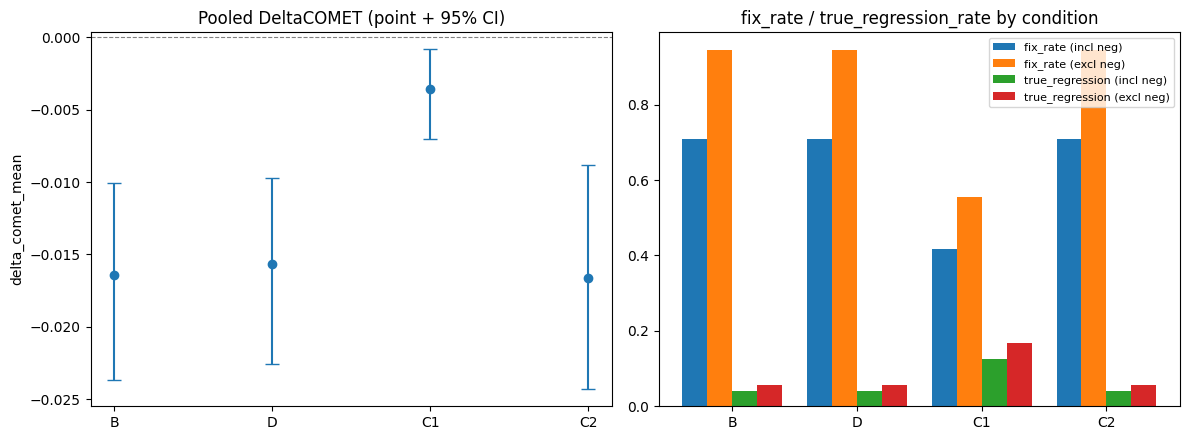

In [16]:
print(f"{'condition':<10}{'delta_comet':>14}{'fix_rate(incl)':>16}{'fix_rate(excl)':>16}{'true_reg(incl)':>16}{'true_reg(excl)':>16}")
for row in scorecard:
    if row.get("pooled_delta_comet_mean") is None:
        print(f"{row['condition']:<10}{'N/A (' + str(row.get('status')) + ')':>14}")
        continue
    print(
        f"{row['condition']:<10}"
        f"{row['pooled_delta_comet_mean']:>14.4f}"
        f"{row['fix_rate_including_negation_n240']:>16.3f}"
        f"{row['fix_rate_excluding_negation_n180']:>16.3f}"
        f"{row['true_regression_rate_including_negation_n240']:>16.3f}"
        f"{row['true_regression_rate_excluding_negation_n180']:>16.3f}"
    )

print()
print(f"condition_c_verdict = {condition_c_verdict}")
print(f"fix_rate_advantage (C2-C1) including negation = {fix_rate_advantage_240_including_negation['point_estimate']:.4f} "
      f"CI={fix_rate_advantage_240_including_negation['ci95']}")
print(f"fix_rate_advantage (C2-C1) excluding negation = {fix_rate_advantage_180_excluding_negation['point_estimate']:.4f} "
      f"CI={fix_rate_advantage_180_excluding_negation['ci95']}")
print(f"direction_verified (incl smaller in magnitude than excl) = {direction_verified}")

plottable = [row for row in scorecard if row.get("pooled_delta_comet_mean") is not None]
labels = [row["condition"] for row in plottable]
means = [row["pooled_delta_comet_mean"] for row in plottable]
err_lo = [m - row["pooled_delta_comet_ci95"][0] for m, row in zip(means, plottable)]
err_hi = [row["pooled_delta_comet_ci95"][1] - m for m, row in zip(means, plottable)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].errorbar(labels, means, yerr=[err_lo, err_hi], fmt="o", capsize=5, color="tab:blue")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_title("Pooled DeltaCOMET (point + 95% CI)")
axes[0].set_ylabel("delta_comet_mean")

x = np.arange(len(labels))
width = 0.2
axes[1].bar(x - 1.5 * width, [row["fix_rate_including_negation_n240"] for row in plottable], width, label="fix_rate (incl neg)")
axes[1].bar(x - 0.5 * width, [row["fix_rate_excluding_negation_n180"] for row in plottable], width, label="fix_rate (excl neg)")
axes[1].bar(x + 0.5 * width, [row["true_regression_rate_including_negation_n240"] for row in plottable], width, label="true_regression (incl neg)")
axes[1].bar(x + 1.5 * width, [row["true_regression_rate_excluding_negation_n180"] for row in plottable], width, label="true_regression (excl neg)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("fix_rate / true_regression_rate by condition")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()